## **Task 0**

a) Name of the dataset is "Wholesale customers", available at https://archive.ics.uci.edu/dataset/292/wholesale+customers

b) The dataset is about clients o a wholesale distributor. It contains the annual spending of monetary units on different product categories. The variables are: Channel, Region, Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen. The dataset has 440 rows, which seems reasonable. Honestly, I am not completely sure how I will use the dataset but I imagine I'll figure out something interesting.

c)

In [5]:
!pip install ucimlrepo

# Summary stats with describe()

from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

wholesale_customers = fetch_ucirepo(id=292)
df = wholesale_customers.data.features

print(df.describe())

          Channel          Fresh          Milk       Grocery        Frozen  \
count  440.000000     440.000000    440.000000    440.000000    440.000000   
mean     1.322727   12000.297727   5796.265909   7951.277273   3071.931818   
std      0.468052   12647.328865   7380.377175   9503.162829   4854.673333   
min      1.000000       3.000000     55.000000      3.000000     25.000000   
25%      1.000000    3127.750000   1533.000000   2153.000000    742.250000   
50%      1.000000    8504.000000   3627.000000   4755.500000   1526.000000   
75%      2.000000   16933.750000   7190.250000  10655.750000   3554.250000   
max      2.000000  112151.000000  73498.000000  92780.000000  60869.000000   

       Detergents_Paper    Delicassen  
count        440.000000    440.000000  
mean        2881.493182   1524.870455  
std         4767.854448   2820.105937  
min            3.000000      3.000000  
25%          256.750000    408.250000  
50%          816.500000    965.500000  
75%         3922.

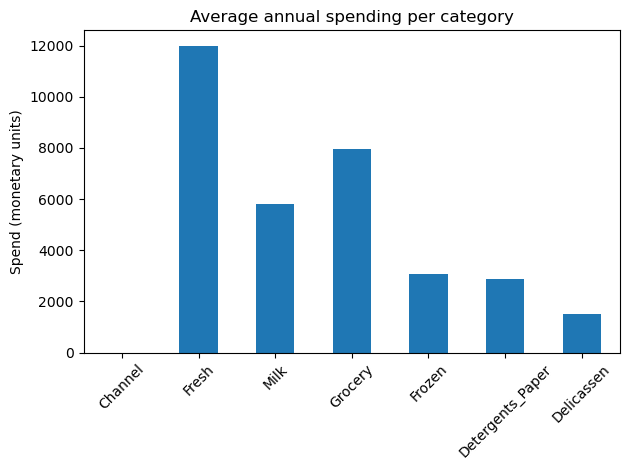

In [3]:
# Visualization 1
df.mean().plot(kind="bar")
plt.title("Average annual spending per category")
plt.ylabel("Spend (monetary units)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

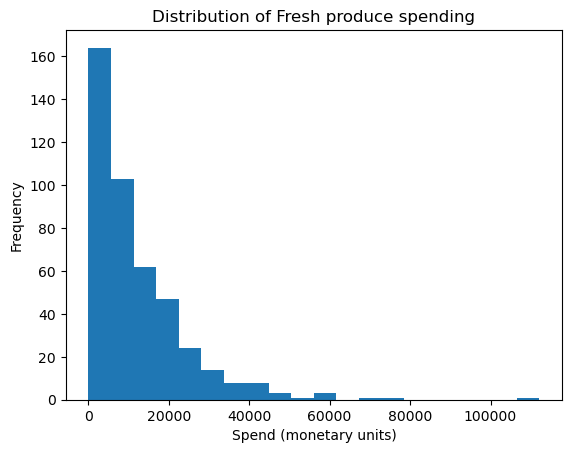

In [4]:
# Visualization 2
df["Fresh"].plot(kind="hist", bins=20)
plt.title("Distribution of Fresh produce spending")
plt.xlabel("Spend (monetary units)")
plt.show()

## **Task 1**

In [3]:
!pip install python-dotenv

from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("API_KEY")

print(api_key[:5] + "...")

e8900...


## **Task 2**

In [19]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("API_KEY")

# a) Fetch EoD for tickers
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
all_data = []

for ticker in tickers:
    url = (f"http://api.marketstack.com/v1/eod"
           f"?access_key={api_key}"
           f"&symbols={ticker}"
           f"&date_from=2026-03-01"
           f"&date_to=2026-03-31")
    response = requests.get(url)
    all_data.extend(response.json()["data"])

# b) Convert to DataFrame and print first 5 rows
df = pd.DataFrame(all_data)
print(df.head())

# c) Summary stats
print(df.groupby("symbol")["close"].describe())

returns = df.groupby("symbol").apply(
    lambda g: (g.sort_values("date")["close"].iloc[-1] /
               g.sort_values("date")["close"].iloc[0] - 1) * 100,
    include_groups=False
).round(2)

print("\nMonthly return (%):")
print(returns)
print(f"\nBest:  {returns.idxmax()} ({returns.max()}%)")
print(f"Worst: {returns.idxmin()} ({returns.min()}%)")

     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:00:00+0000  
3 

## **Task 3**

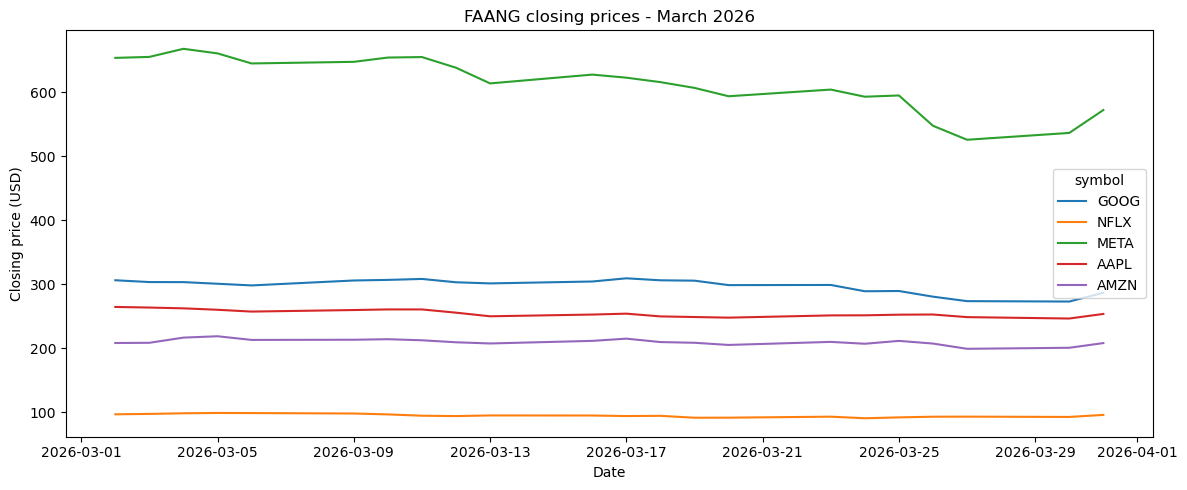

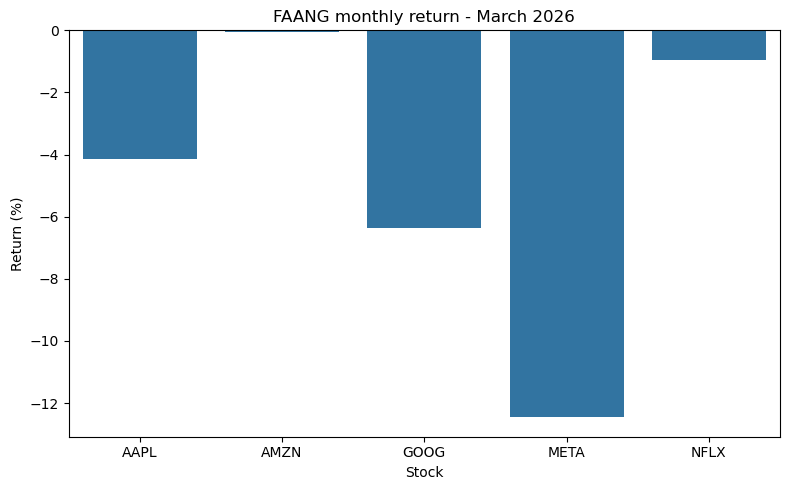

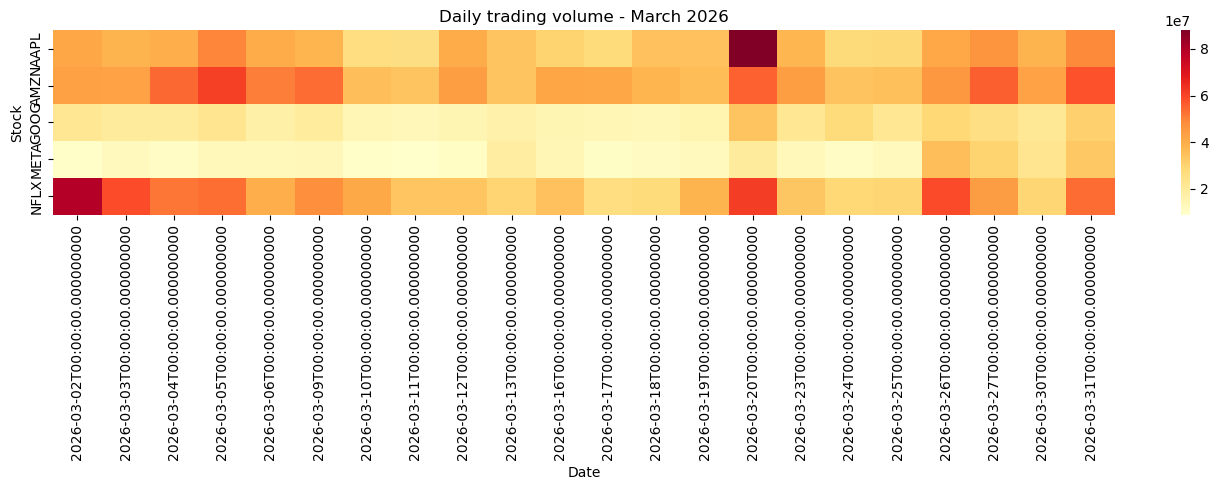

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sorting dates
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# a) Line chart
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="date", y="close", hue="symbol")
plt.title("FAANG closing prices - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing price (USD)")
plt.tight_layout()
plt.show()

# b) Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=returns.index, y=returns.values)
plt.title("FAANG monthly return - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

# c) Heatmap
volume_pivot = df.pivot(index="symbol", columns="date", values="volume")
plt.figure(figsize=(14, 5))
sns.heatmap(volume_pivot, cmap="YlOrRd")
plt.title("Daily trading volume - March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

## **Task 4**

In [8]:
import json
import os

# a) Exports JSON data to exports/stockdata.json
os.makedirs("exports", exist_ok=True)  # creates the folder if it doesn't already exist
with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f)

# b) Export DataFrame to exports/stockdata.csv
df.to_csv("exports/stockdata.csv", index=False)

# c) Load and print first 5 rows
with open("exports/stockdata.json", "r") as f:
    loaded_json = json.load(f)
print(pd.DataFrame(loaded_json).head())

loaded_csv = pd.read_csv("exports/stockdata.csv")
print(loaded_csv.head())

     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:00:00+0000  
3 

## **Task 5**

In [12]:
import sqlite3
import pandas as pd

# a) Connect and list all tables
conn = sqlite3.connect("northwind.db")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

# b) Products with unit price >30
df_products = pd.read_sql("""
    SELECT ProductName, UnitPrice, UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
""", conn)
print(df_products)

# c) Orders shipped to Germany and line total
df_germany = pd.read_sql("""
    SELECT c.CompanyName, o.OrderID, o.OrderDate, o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = 'Germany'
""", conn)
print(df_germany)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories
                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Th

## **Task 6**

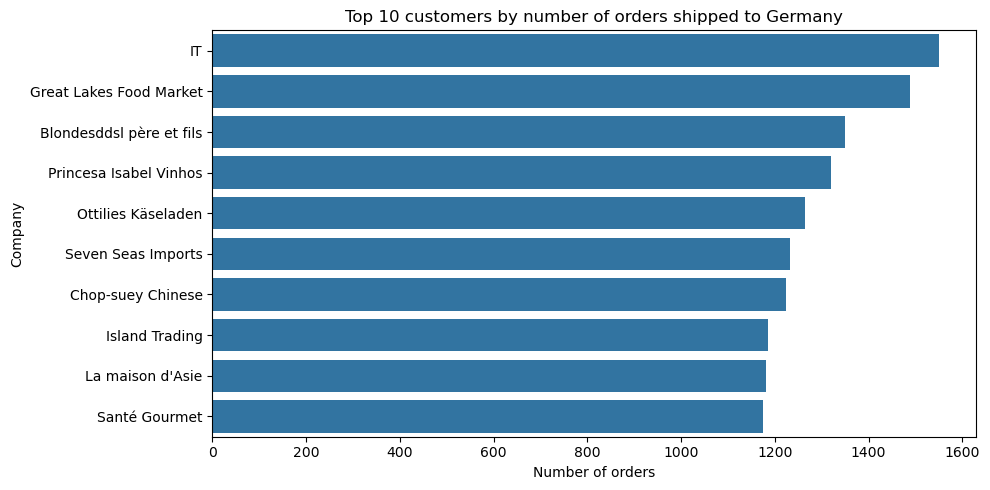

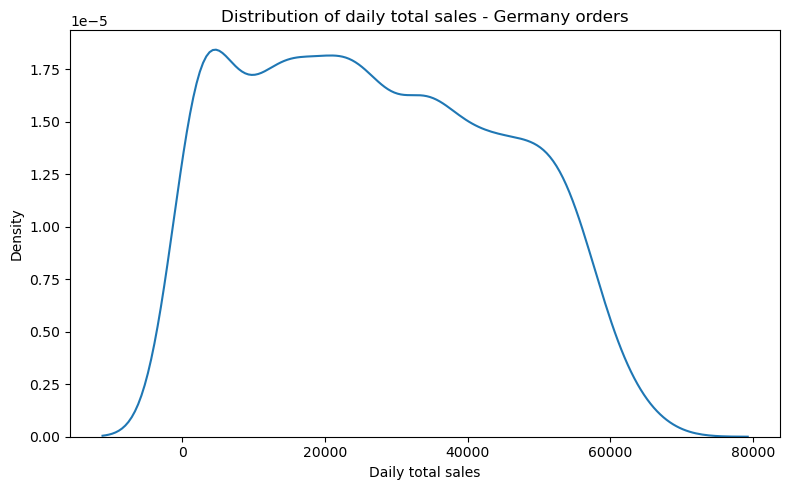

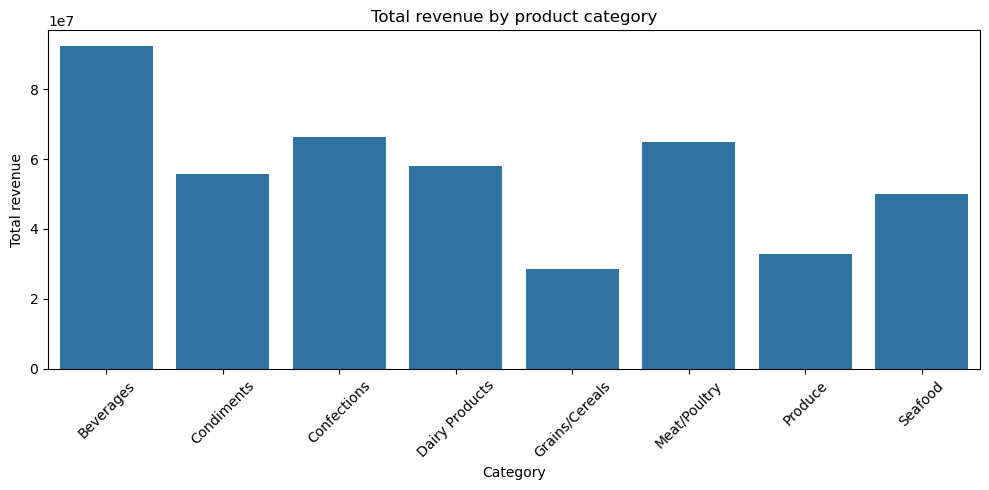

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# a) Bar plot
top10 = df_germany.groupby("CompanyName")["OrderID"].count().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 customers by number of orders shipped to Germany")
plt.xlabel("Number of orders")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

# b) Density (KDE) plot 
daily_sales = df_germany.groupby("OrderDate")["LineTotal"].sum()

plt.figure(figsize=(8, 5))
sns.kdeplot(daily_sales)
plt.title("Distribution of daily total sales - Germany orders")
plt.xlabel("Daily total sales")
plt.tight_layout()
plt.show()

# c) New query
df_categories = pd.read_sql("""
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_categories, x="CategoryName", y="TotalRevenue")
plt.title("Total revenue by product category")
plt.xlabel("Category")
plt.ylabel("Total revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Task 7**

In [16]:
import time
import pandas as pd

# a) Load Products and Categories
df_products_full = pd.read_sql("SELECT * FROM Products", conn)
df_categories_full = pd.read_sql("SELECT * FROM Categories", conn)
print(df_products_full.head())
print(df_categories_full.head())

# b) Inner join on CategoryID using pandas
df_merged = df_products_full.merge(df_categories_full, on="CategoryID", how="inner")
print(df_merged.head())

# c) Compare execution speed
start = time.time()
df_sql = pd.read_sql("""
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
""", conn)
sql_time = time.time() - start

start = time.time()
df_od = pd.read_sql("SELECT * FROM 'Order Details'", conn)
df_p  = pd.read_sql("SELECT * FROM Products", conn)
df_c  = pd.read_sql("SELECT * FROM Categories", conn)
df_pandas = (df_od.merge(df_p, on="ProductID")
                  .merge(df_c, on="CategoryID"))
df_pandas["TotalRevenue"] = df_pandas["UnitPrice_x"] * df_pandas["Quantity"]
df_pandas = df_pandas.groupby("CategoryName")["TotalRevenue"].sum().reset_index()
pandas_time = time.time() - start

print(f"SQL time:    {sql_time:.4f}s")
print(f"Pandas time: {pandas_time:.4f}s")

   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4            1  
  

### *SQL vs Pandas*

I'm a bit surprised by the fact that SQL was 2x faster than Pandas. I would've assumed there was some difference, but double is a bit surprising

## **Task 8**

In [17]:
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month":      ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product":    ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# a) Wide to long using pd.melt
print("Before:\n", wide_data)
melted = wide_data.melt(id_vars="store", var_name="quarter", value_name="sales")
print("After:\n", melted)

# b) Long to wide using .pivot
print("Before:\n", long_data)
pivoted = long_data.pivot(index="month", columns="product", values="units_sold")
print("After:\n", pivoted)

# c) Convert both back
back_to_wide = melted.pivot(index="store", columns="quarter", values="sales").reset_index()
back_to_wide.columns.name = None  # removes the "quarter" label from column axis
print("Back to wide:\n", back_to_wide)

back_to_long = pivoted.reset_index().melt(id_vars="month", var_name="product", value_name="units_sold")
back_to_long = back_to_long.sort_values("month").reset_index(drop=True)
print("Back to long:\n", back_to_long)

Before:
       store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500
After:
        store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500
Before:
   month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130
After:
 product  Laptop  Phone
month                 
Feb          50    110
Jan          45    120
Mar          55    130
Back to wide:
       store  Q1_sales  Q2_sales  Q3_sales 

______________________________________________________________________________________________________________

# *AI Usage*

Claude was used to help/troubleshoot with some tasks, Claude helped with generating code for some of the tasks.